## Import log files and count distinct txs

In [10]:
#===================================================================================\
# Count number of distinct txs in logs
#===================================================================================\\
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
from datetime import datetime


# ---------------------------------------------------------
# STEP 1: CONFIGURATION
# ---------------------------------------------------------
# Path to the directory containing the log files
# Use the variable appropriate for your test case
empty_blocks = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'
test_490_txs = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
forks_9 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-22_11-56-34_to_2026-01-22_11-59-12'
Jan23_rc4 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-23_21-40-00_to_2026-01-23_21-47-00/'
Jan26_rc5_fix = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-26_14-16-27_to_2026-01-26_14-20-17/'
Jan27_rc6_tomas_1_94_weight = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_13-01-35_to_2026-01-27_13-13-00/'
Jan27_rc6_20batch_6sec_delay = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_13-53-28_to_2026-01-27_13-57-50/'
Jan27_rc6_15batch_8sec_delay = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_14-10-00_to_2026-01-27_14-16-01'
Jan26_rc6_10batch_6sec_delay = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_14-31-07_to_2026-01-27_14-38-56'
Jan26_rc6_10batch_6sec_dealy_txpoolmax_10 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_14-54-51_to_2026-01-27_15-01-36'
more_than_txpool_100_12 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_15-07-53_to_2026-01-27_15-10-33/'
txpool5_batch5_delay6 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28'
# Set active log directory here
LOG_DIR = txpool5_batch5_delay6

RELAYS = ["ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"]
BLOCK_PRODUCERS = ["alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver"]
NODES = RELAYS + BLOCK_PRODUCERS

# ---------------------------------------------------------
# STEP 2: DEFINE PARSING LOGIC
# ---------------------------------------------------------

def count_validated_transactions(log_directory, nodes):
    """
    Reads log files and counts unique 'Validated Midnight transaction' entries
    using regex. Returns a set of all unique TXs and a dict of counts per node.
    """
    total_unique_txs = set()
    node_stats = {}
    files_processed = 0

    # Regex matches: Validated Midnight transaction "618804..."
    tx_pattern = re.compile(r'Validated Midnight transaction "([a-fA-F0-9]+)"')

    print(f"Scanning logs in: {log_directory}\n")

    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        node_unique_txs = set()
        
        if not os.path.exists(file_path):
            # If file doesn't exist, we just record 0 for this node
            node_stats[node] = 0
            # print(f"⚠️ Log file not found for: {node}") # Optional warning
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    match = tx_pattern.search(line)
                    if match:
                        tx_hash = match.group(1)
                        node_unique_txs.add(tx_hash)
            
            # Update stats
            node_stats[node] = len(node_unique_txs)
            total_unique_txs.update(node_unique_txs)
            files_processed += 1
            
        except Exception as e:
            print(f"Error reading file for {node}: {e}")
            node_stats[node] = 0

    return total_unique_txs, node_stats, files_processed

# ---------------------------------------------------------
# STEP 3: RUN ANALYSIS
# ---------------------------------------------------------

unique_tx_set, node_counts, files_count = count_validated_transactions(LOG_DIR, NODES)

# Print per-node statistics
for node in NODES:
    count = node_counts.get(node, 0)
    print(f"{node}: {count} distinct Validated transactions")

TOTAL_UNIQUE_TXS = len(unique_tx_set)
print("\n" + "=" * 50)
print(f"TOTAL DISTINCT TRANSACTIONS ACROSS ALL NODES: {TOTAL_UNIQUE_TXS}")
print("=" * 50)


Scanning logs in: /home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28

ferdie: 134 distinct Validated transactions
george: 131 distinct Validated transactions
henry: 133 distinct Validated transactions
iris: 129 distinct Validated transactions
jack: 130 distinct Validated transactions
paul: 132 distinct Validated transactions
quinn: 133 distinct Validated transactions
rita: 134 distinct Validated transactions
sam: 133 distinct Validated transactions
tom: 133 distinct Validated transactions
alice: 106 distinct Validated transactions
bob: 108 distinct Validated transactions
charlie: 109 distinct Validated transactions
dave: 110 distinct Validated transactions
eve: 107 distinct Validated transactions
kate: 106 distinct Validated transactions
leo: 106 distinct Validated transactions
mike: 108 distinct Validated transactions
nina: 107 distinct Validated transactions
oliver: 107 distinct Validated transactions

TOTAL DISTIN

In [11]:
#===================================================================================
# Count Extrinsics, Max Txs, & Calculate Finalization Duration
#===================================================================================

NODES = BLOCK_PRODUCERS

# ---------------------------------------------------------
# STEP 2: ANALYSIS LOGIC
# ---------------------------------------------------------

def analyze_traffic(log_directory, nodes):
    
    block_tx_counts = {}      # {block_num: tx_count}
    block_creation_times = {} # {block_num: datetime_obj}
    block_finalization_times = {} # {block_num: datetime_obj}

    # Regex 1: Block Creation (Prepared block)
    rx_prepared = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*Prepared block for proposing at (\d+).*extrinsics_count: (\d+)')

    # Regex 2: Standard Finalization Event (Full Hash)
    rx_finalized_event = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*event=Finalized \{ hash: (0x[a-f0-9]+)')

    # Regex 3: Idle Status Finalization (Block Number + Short Hash)
    rx_finalized_idle = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*finalized #(\d+)')

    # Regex 4: Import Event (Maps Hash -> Number)
    rx_imported = re.compile(r'Imported #(\d+) \(.*→ (0x[a-f0-9]+)\)')

    # Map to link Hash -> Block Number
    hash_to_block_num = {}

    print(f"Scanning logs in: {log_directory}\n")

    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    # 1. Parse Block Creation
                    match_prep = rx_prepared.search(line)
                    if match_prep:
                        ts_str, blk_num, ext_count = match_prep.groups()
                        blk_num = int(blk_num)
                        ext_count = int(ext_count)
                        
                        if ext_count > 2:
                            # Subtract 2 system extrinsics (Timestamp + Inherent)
                            user_txs = ext_count - 2
                            block_tx_counts[blk_num] = user_txs
                            
                            ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            if blk_num not in block_creation_times or ts < block_creation_times[blk_num]:
                                block_creation_times[blk_num] = ts

                    # 2. Map Hashes to Block Numbers
                    match_imp = rx_imported.search(line)
                    if match_imp:
                        blk_num, blk_hash = match_imp.groups()
                        hash_to_block_num[blk_hash] = int(blk_num)

                    # 3. Parse Standard Finalization Event
                    match_fin = rx_finalized_event.search(line)
                    if match_fin:
                        ts_str, blk_hash = match_fin.groups()
                        if blk_hash in hash_to_block_num:
                            blk_num = hash_to_block_num[blk_hash]
                            ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            if blk_num not in block_finalization_times or ts < block_finalization_times[blk_num]:
                                block_finalization_times[blk_num] = ts

                    # 4. Parse Idle Status Finalization
                    match_idle = rx_finalized_idle.search(line)
                    if match_idle:
                        ts_str, blk_num = match_idle.groups()
                        blk_num = int(blk_num)
                        ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                        if blk_num not in block_finalization_times or ts < block_finalization_times[blk_num]:
                            block_finalization_times[blk_num] = ts

        except Exception as e:
            print(f"Error reading file for {node}: {e}")

    return block_tx_counts, block_creation_times, block_finalization_times

# ---------------------------------------------------------
# STEP 3: CALCULATE & PRINT
# ---------------------------------------------------------

tx_counts, creation_times, finalization_times = analyze_traffic(LOG_DIR, NODES)

TOTAL_TXS_VALIDATED = sum(tx_counts.values())
MAX_TXS_IN_SINGLE_BLOCK = max(tx_counts.values()) if tx_counts else 0
TOTAL_TX_PROCESSING_TIME = 0
print(f"{'BLOCK':<8} | {'USER TXS':<10} | {'CREATED AT':<26} | {'FINALIZED AT':<26}")
print("-" * 75)

sorted_blocks = sorted(tx_counts.keys())

for blk in sorted_blocks:
    c_time = creation_times.get(blk, "N/A")
    f_time = finalization_times.get(blk, "N/A")
    print(f"{blk:<8} | {tx_counts[blk]:<10} | {str(c_time):<26} | {str(f_time):<26}")

print("-" * 75)
print(f"TOTAL_TXS_VALIDATED:     {TOTAL_TXS_VALIDATED}")
print(f"MAX_TXS_IN_SINGLE_BLOCK: {MAX_TXS_IN_SINGLE_BLOCK}")

START_TIME = 0
END_TIME = 0
if sorted_blocks:
    first_block = sorted_blocks[0]
    last_block = sorted_blocks[-1]

    start_time = creation_times.get(first_block)
    end_time = finalization_times.get(last_block)

    if start_time and end_time and isinstance(start_time, datetime) and isinstance(end_time, datetime):
        TOTAL_TX_PROCESSING_TIME = (end_time - start_time).total_seconds()
        START_TIME = start_time
        END_TIME = end_time
        print(f"\nTime Duration (First Block Start -> Last Block Finalized): {TOTAL_TX_PROCESSING_TIME:.3f} seconds")
        print(f"Start Block ({first_block}): {start_time}")
        print(f"End Block   ({last_block}): {end_time}")
    else:
        print("\nCould not calculate duration: Missing timestamps.")
        if not isinstance(start_time, datetime): print(f"Missing creation time for block {first_block}")
        if not isinstance(end_time, datetime): print(f"Missing finalization time for block {last_block}")
else:
    print("\nNo blocks with > 2 extrinsics found.")

Scanning logs in: /home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28

BLOCK    | USER TXS   | CREATED AT                 | FINALIZED AT              
---------------------------------------------------------------------------
3608     | 5          | 2026-01-27 21:34:55.355000 | 2026-01-27 21:35:08.200000
3612     | 5          | 2026-01-27 21:35:19.444000 | 2026-01-27 21:35:32.421000
3615     | 5          | 2026-01-27 21:35:37.453000 | 2026-01-27 21:35:49.799000
3619     | 5          | 2026-01-27 21:36:01.457000 | 2026-01-27 21:36:21.443000
3622     | 5          | 2026-01-27 21:36:25.576000 | 2026-01-27 21:36:38.208000
3625     | 5          | 2026-01-27 21:36:43.098000 | 2026-01-27 21:36:55.482000
3629     | 5          | 2026-01-27 21:37:07.372000 | 2026-01-27 21:37:19.641000
3632     | 5          | 2026-01-27 21:37:25.608000 | 2026-01-27 21:37:39.486000
3635     | 5          | 2026-01-27 21:37:43.096000 | 2026-01-27 

3. Scanning TxPool metrics for specific nodes: ['charlie', 'ferdie']...

 FINAL BENCHMARK RESULTS
Total Unique Validated TXs:  102
Active Duration:             494.20 seconds
Start Time (Mempool):        2026-01-27 21:34:55.355000
End Time (Finalized):        2026-01-27 21:43:09.556000
--------------------------------------------------
Average TPS (Global):        0.21 TX/s
Mempool Drain Rate:          0.01 TX/s
--------------------------------------------------
Max TXs in Single Block:     5
Max Mempool Depth:           5 txs
Avg Mempool Depth:           3.9 txs

Generating Plots...
Plot saved as 'benchmark_summary_plot.png'


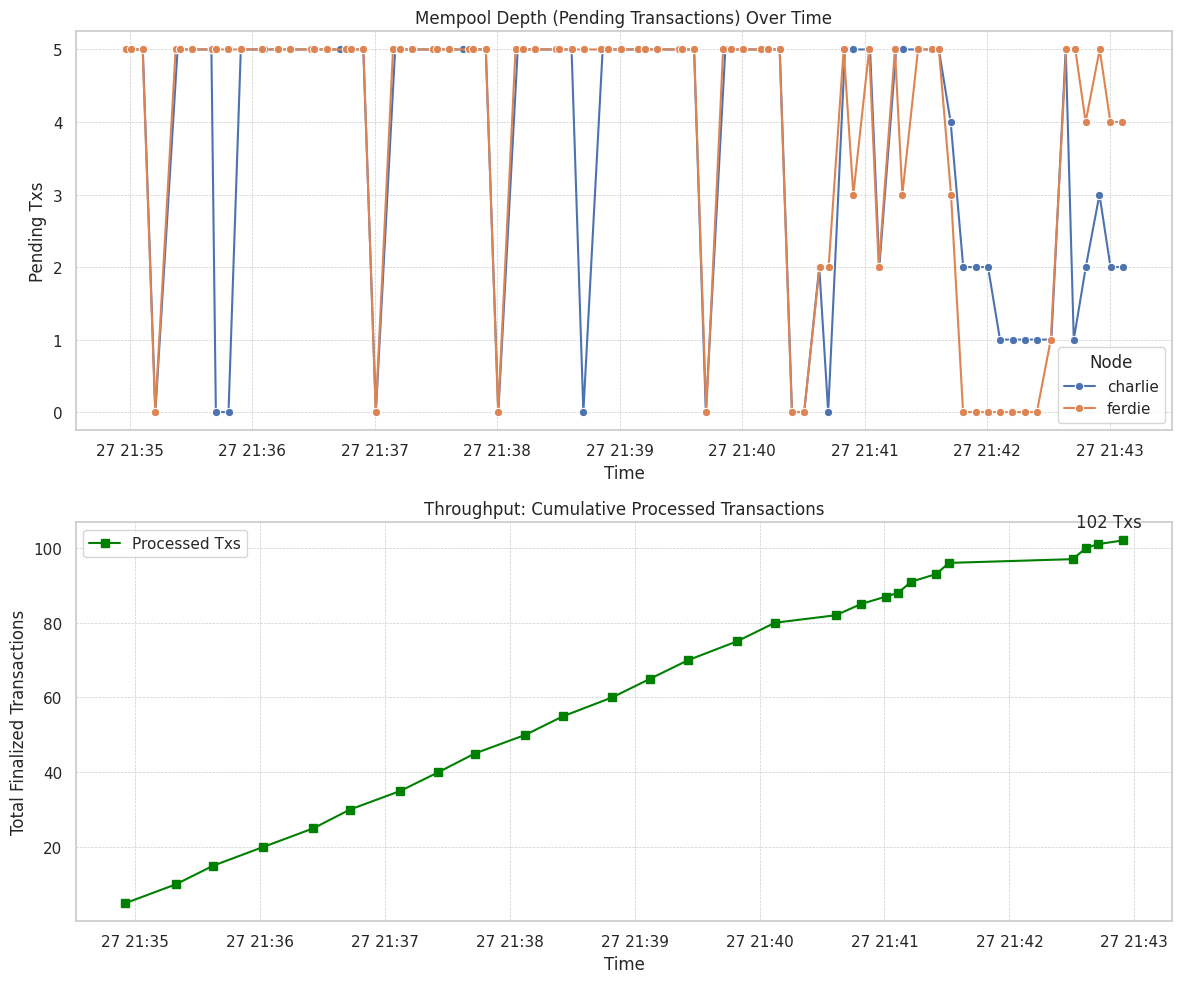

In [12]:
# Global list of nodes to check for TxPool metrics (Saves time/resources)
TX_POOL_NODES = ['charlie', 'ferdie']

# ==========================================
# PART 3: GET TXPOOL (MEMPOOL) METRICS
# ==========================================
def get_mempool_stats(log_directory, nodes_to_scan):
    print(f"3. Scanning TxPool metrics for specific nodes: {nodes_to_scan}...")
    
    len_pattern = re.compile(r'mempool_len=(\d+)')
    json_pattern = re.compile(r'"numTxs":(\d+)')
    
    pool_data = []

    for node in nodes_to_scan: 
        file_path_txt = os.path.join(log_directory, f"{node}.txt")
        file_path_log = os.path.join(log_directory, f"{node}.log")
        file_path = file_path_txt if os.path.exists(file_path_txt) else file_path_log

        if not os.path.exists(file_path):
            continue

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                count = -1
                m1 = len_pattern.search(line)
                if m1:
                    count = int(m1.group(1))
                else:
                    m2 = json_pattern.search(line)
                    if m2:
                        count = int(m2.group(1))
                
                if count > -1:
                    try:
                        ts_str = line[:23]
                        dt = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                        pool_data.append({'time': dt, 'node': node, 'pool_count': count})
                    except ValueError:
                        continue
                        
    return pd.DataFrame(pool_data)

total_tx_count = TOTAL_TXS_VALIDATED

# 3. TxPool Metrics
df_pool = get_mempool_stats(LOG_DIR, TX_POOL_NODES) 
    
tps = total_tx_count / TOTAL_TX_PROCESSING_TIME if TOTAL_TX_PROCESSING_TIME > 0 else 0

if not df_pool.empty:
    # Filter pool data to relevant window
    mask = (df_pool['time'] >= start_time) & (df_pool['time'] <= end_time)
    df_pool_window = df_pool.loc[mask]
    
    if not df_pool_window.empty:
        max_pool_depth = df_pool_window['pool_count'].max()
        avg_pool_depth = df_pool_window['pool_count'].mean()
        
        # CALCULATE DRAIN RATE
        peak_idx = df_pool_window['pool_count'].idxmax()
        peak_time = df_pool_window.loc[peak_idx, 'time']
        peak_val = df_pool_window.loc[peak_idx, 'pool_count']
        
        drain_duration = (end_time - peak_time).total_seconds()
        
        if drain_duration > 1:
            drain_rate_tps = peak_val / drain_duration

    print("\n" + "="*50)
    print(" FINAL BENCHMARK RESULTS")
    print("="*50)
    print(f"Total Unique Validated TXs:  {total_tx_count}")
    print(f"Active Duration:             {TOTAL_TX_PROCESSING_TIME:.2f} seconds")
    print(f"Start Time (Mempool):        {START_TIME}")
    print(f"End Time (Finalized):        {END_TIME}")
    print("-" * 50)
    print(f"Average TPS (Global):        {tps:.2f} TX/s")
    print(f"Mempool Drain Rate:          {drain_rate_tps:.2f} TX/s")
    print("-" * 50)
    print(f"Max TXs in Single Block:     {MAX_TXS_IN_SINGLE_BLOCK}")
    print(f"Max Mempool Depth:           {max_pool_depth} txs")
    print(f"Avg Mempool Depth:           {avg_pool_depth:.1f} txs")
    print("="*50)
else:
    print("No non-empty blocks found to calculate duration.")


# ==========================================
# PART 4: PLOTTING
# ==========================================
print("\nGenerating Plots...")

# 1. Prepare Block Data for Throughput Plot
block_data = []
for blk, count in tx_counts.items():
    if blk in creation_times:
        block_data.append({'time': creation_times[blk], 'tx_count': count})

df_blocks = pd.DataFrame(block_data).sort_values(by='time')
if not df_blocks.empty:
    df_blocks['cumulative_txs'] = df_blocks['tx_count'].cumsum()

# Create Figure with 2 Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# PLOT 1: Mempool Depth Over Time
if not df_pool_window.empty:
    sns.lineplot(data=df_pool_window, x='time', y='pool_count', hue='node', marker='o', ax=ax1)
    ax1.set_title('Mempool Depth (Pending Transactions) Over Time')
    ax1.set_ylabel('Pending Txs')
    ax1.set_xlabel('Time')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.legend(title='Node')
else:
    ax1.text(0.5, 0.5, 'No Mempool Data Found', horizontalalignment='center', verticalalignment='center')
    ax1.set_title('Mempool Depth (No Data)')

# PLOT 2: Cumulative Throughput
if not df_blocks.empty:
    ax2.plot(df_blocks['time'], df_blocks['cumulative_txs'], marker='s', color='green', linestyle='-', label='Processed Txs')
    ax2.set_title('Throughput: Cumulative Processed Transactions')
    ax2.set_ylabel('Total Finalized Transactions')
    ax2.set_xlabel('Time')
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.legend()
    
    # Annotate final count
    last_time = df_blocks['time'].iloc[-1]
    last_count = df_blocks['cumulative_txs'].iloc[-1]
    ax2.annotate(f"{last_count} Txs", (last_time, last_count), textcoords="offset points", xytext=(-10,10), ha='center')
else:
    ax2.text(0.5, 0.5, 'No Block Transaction Data', horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('benchmark_summary_plot.png')
print("Plot saved as 'benchmark_summary_plot.png'")

Scanning for block creation events in: /home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28
Found 103 blocks. Plotting...
Graph saved as 'block_creation_timeline.png'


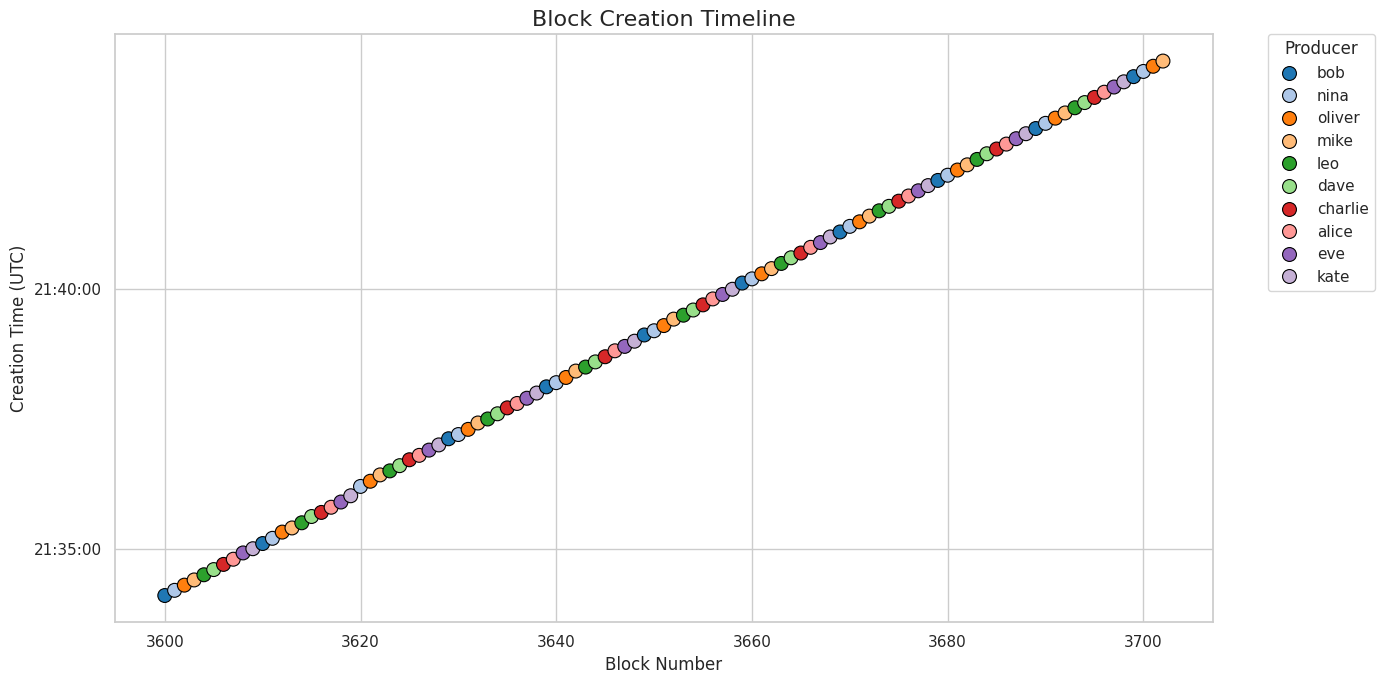

In [13]:
#===================================================================================\
# Plot block production timeline
#===================================================================================\\


# ---------------------------------------------------------
# STEP 4: PARSE BLOCK CREATION TIMES (Re-parsing for Timeline)
# ---------------------------------------------------------
# We need to scan the logs again specifically for block creation events 
# to build the creation_registry required for the plot.

creation_registry = {} 

# Regex to capture timestamp and creation event
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)")

print(f"Scanning for block creation events in: {LOG_DIR}")

for node in NODES:
    filepath = os.path.join(LOG_DIR, f"{node}.txt")
    
    if not os.path.exists(filepath):
        continue
        
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            # Check for creation line first (optimization)
            create_match = creation_pattern.search(line)
            if create_match:
                # Extract Timestamp
                ts_match = timestamp_pattern.search(line)
                if not ts_match: continue
                
                try:
                    ts_str = ts_match.group(1)
                    if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26]
                    current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                    
                    block_num = int(create_match.group(1))
                    
                    # Store data
                    creation_registry[block_num] = {
                        'time': current_time,
                        'creator': node
                    }
                except ValueError:
                    continue

# ---------------------------------------------------------
# STEP 5: PLOT BLOCK CREATION TIMELINE
# ---------------------------------------------------------

if not creation_registry:
    print("No block creation events found. Check log path.")
else:
    # Convert registry to DataFrame
    creation_data = []
    for block_num, info in creation_registry.items():
        creation_data.append({
            "Block": block_num,
            "Timestamp": info['time'],
            "Creator": info['creator']
        })

    df_creation = pd.DataFrame(creation_data).sort_values("Block")

    print(f"Found {len(df_creation)} blocks. Plotting...")

    # Setup the Plot
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # 1. Draw a line to show the progression
    sns.lineplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        color="gray",
        alpha=0.3,
        zorder=1
    )

    # 2. Draw points colored by the Creator Node
    plot = sns.scatterplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        hue="Creator",
        palette="tab20",  # Colorful palette for many nodes
        s=100,            # Dot size
        edgecolor="black",
        zorder=2
    )

    # Format Y-Axis to show HH:MM:SS
    plot.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    plt.title("Block Creation Timeline", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Creation Time (UTC)", fontsize=12)

    # Ensure integer ticks on X-axis if valid range
    if df_creation["Block"].nunique() < 20:
        plt.xticks(df_creation["Block"].unique())

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Producer")
    
    plt.tight_layout()
    plt.savefig("block_creation_timeline.png", dpi=300)
    print("Graph saved as 'block_creation_timeline.png'")
    
    plt.show()

Parsed 104 blocks successfully.
    Node  Block  ProductionTime_ms  StartDelay_ms
0  Alice   3607               39.0           43.0
1  Alice   3617              152.0           40.0
2  Alice   3626              147.0           40.0
3  Alice   3636              150.0           38.0
4  Alice   3646             1025.0           44.0


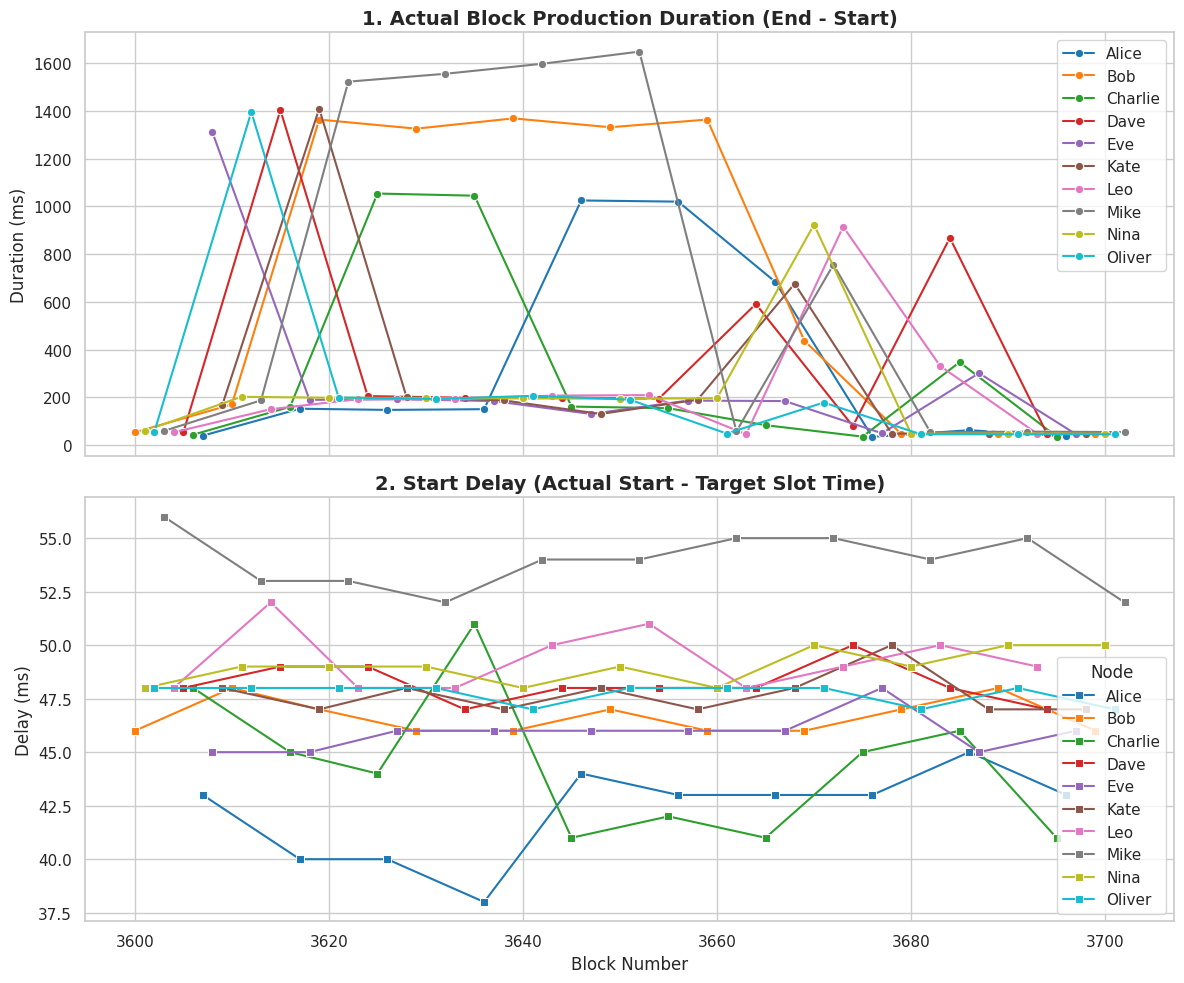

In [14]:
#===================================================================================
# Plot all Block Producer's block production time and the start delay
#===================================================================================

files_to_process = []
for node in BLOCK_PRODUCERS:
    # os.path.join automatically adds the '/' if LOG_DIR doesn't have it
    files_to_process.append(os.path.join(LOG_DIR, f"{node}.txt"))

# # ---------------------------------------------------------
# # STEP 6: PARSE THE LOGS
# # ---------------------------------------------------------

def parse_substrate_logs_robust(file_list):
    data = []
    
    # 1. Regex to capture Timestamp and the rest of the message
    # Matches: 2026-01-15 17:39:36.048  INFO ...
    base_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\s+(.*)")
    
    # 2. Regex for START event (captures Parent Block #)
    # Matches: ... Starting consensus session on top of parent ... (#14406)
    start_pattern = re.compile(r"Starting consensus session on top of parent .* \(#(\d+)\)")
    
    # 3. Regex for END event (captures Current Block #)
    # Matches: ... Prepared block for proposing at 14407 ...
    end_pattern = re.compile(r"Prepared block for proposing at (\d+)")

    for filename in file_list:
        node_name = os.path.splitext(os.path.basename(filename))[0].capitalize()
        
        # Dictionary to store timestamps for each block
        # Structure: { 14407: {'start': datetime, 'end': datetime}, ... }
        block_events = {}
        
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                
                # Extract Timestamp
                base_match = base_pattern.search(line)
                if not base_match: continue
                
                timestamp_str = base_match.group(1)
                message = base_match.group(2)
                
                try:
                    current_time = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S.%f")
                except ValueError:
                    continue

                # --- CHECK FOR START (Parent Block) ---
                start_match = start_pattern.search(message)
                if start_match:
                    parent_block = int(start_match.group(1))
                    # If we are working on top of 14406, we are building 14407
                    target_block = parent_block + 1
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['start'] = current_time
                    continue

                # --- CHECK FOR END (Current Block) ---
                end_match = end_pattern.search(message)
                if end_match:
                    target_block = int(end_match.group(1))
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['end'] = current_time
                    continue

        # --- CALCULATE DURATIONS ---
        # Now we iterate through the dictionary and calculate stats for blocks that have both times
        for block_num, times in block_events.items():
            if 'start' in times and 'end' in times:
                start_time = times['start']
                end_time = times['end']
                
                # A. Production Time
                # Calculate diff in milliseconds
                duration_ms = (end_time - start_time).total_seconds() * 1000
                
                # Sanity check: If duration is negative (rare clock skew?), skip
                if duration_ms < 0: continue

                # B. Start Delay (Ideal Target vs Actual Start)
                # Calculate seconds past the minute
                total_seconds = start_time.second + (start_time.microsecond / 1e6)
                remainder = total_seconds % 6 
                start_delay_ms = remainder * 1000
                
                data.append({
                    "Node": node_name,
                    "Block": block_num,
                    "ProductionTime_ms": duration_ms,
                    "StartDelay_ms": start_delay_ms
                })

    return pd.DataFrame(data)

# Run the parser
df = parse_substrate_logs_robust(files_to_process)

print(f"Parsed {len(df)} blocks successfully.")
if not df.empty:
    print(df.head())
else:
    print("No matching blocks found. Check log paths or regex.")

# ---------------------------------------------------------
# STEP 3: PLOT THE GRAPHS
# ---------------------------------------------------------

if not df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # GRAPH 1: Production Time (Duration)
    # How long did the CPU actually churn to build the block?
    sns.lineplot(
        ax=axes[0],
        data=df, 
        x="Block", 
        y="ProductionTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab10"
    )
    axes[0].set_title("1. Actual Block Production Duration (End - Start)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Duration (ms)")
    axes[0].legend(loc='upper right')

    # GRAPH 2: Start Delay
    # How long after the ideal 6s slot did the node start working?
    sns.lineplot(
        ax=axes[1],
        data=df, 
        x="Block", 
        y="StartDelay_ms", 
        hue="Node", 
        marker="s", # Square marker to distinguish
        palette="tab10"
    )
    axes[1].set_title("2. Start Delay (Actual Start - Target Slot Time)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Delay (ms)")
    axes[1].set_xlabel("Block Number")
    
    # Force Integer X-Axis
    if len(df) < 20:
        axes[1].set_xticks(sorted(df['Block'].unique()))

    plt.tight_layout()
    plt.savefig("block_timing_analysis.png")
    plt.show()
else:
    print("No matching log lines found. Check regex patterns.")

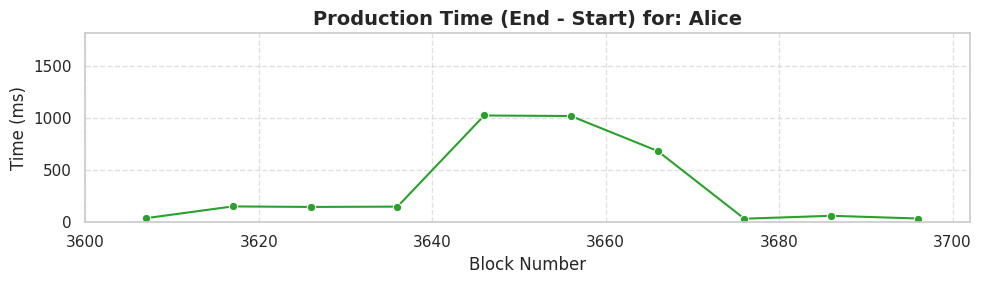

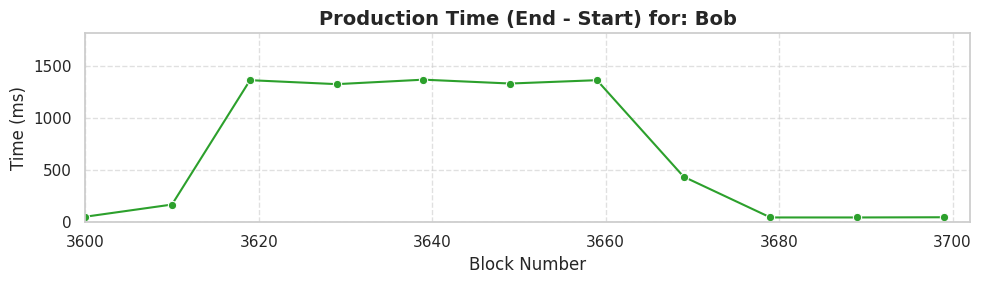

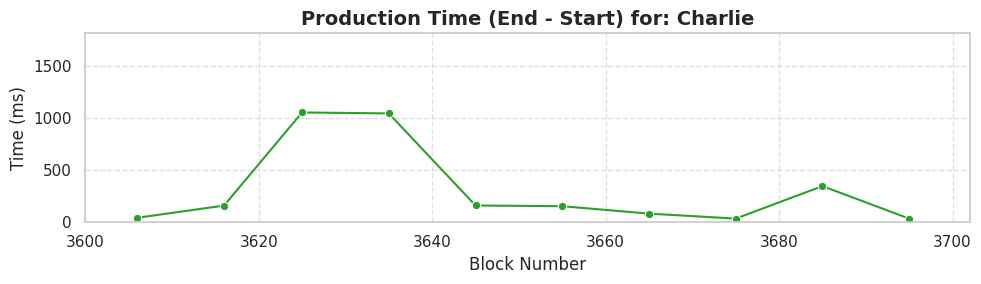

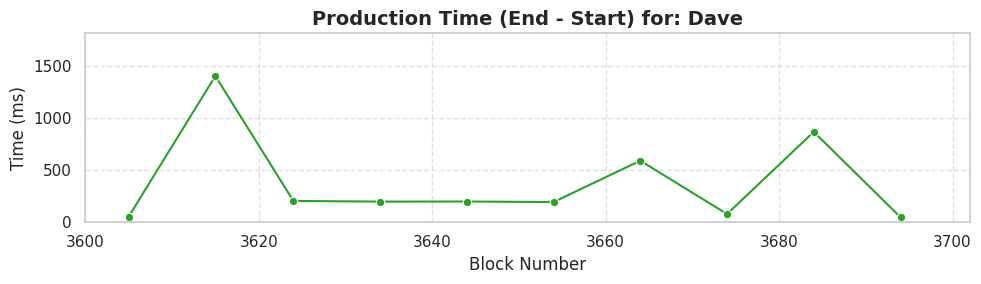

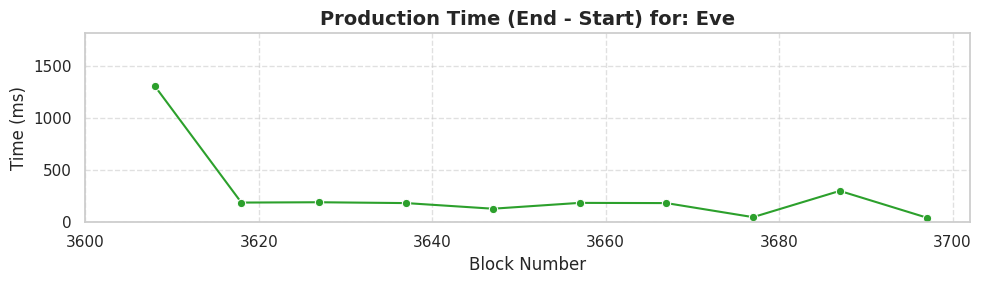

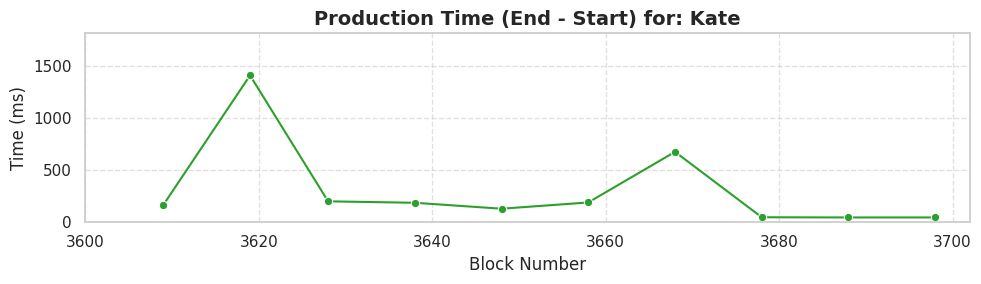

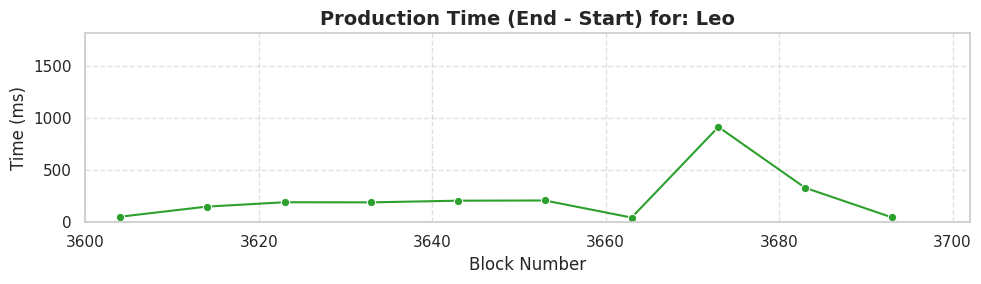

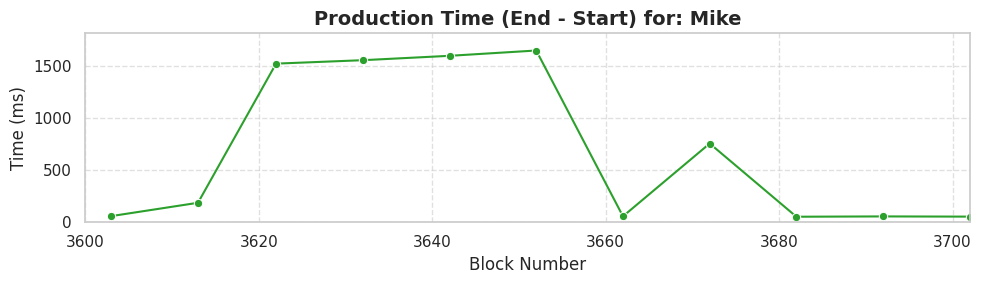

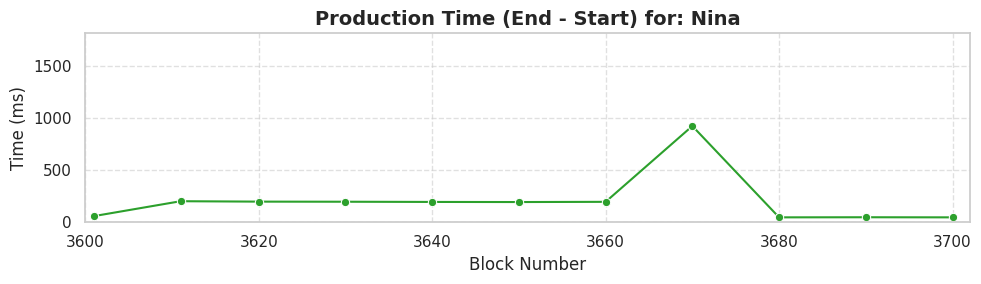

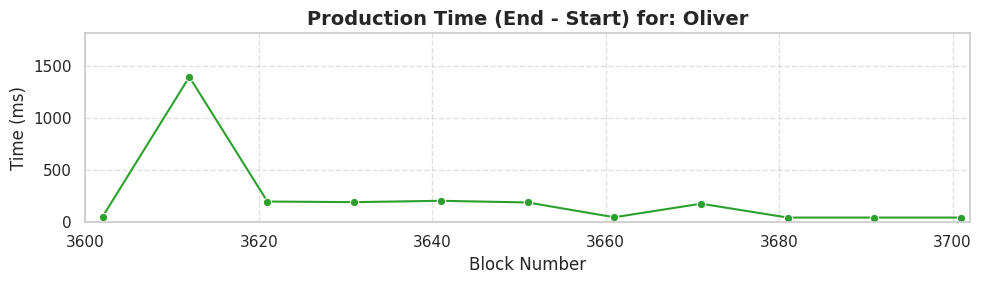

In [15]:
#===================================================================================
# Plot each Block Producer's block production time
#===================================================================================

# 1. Get the list of nodes
unique_nodes = sorted(df['Node'].unique())

# 2. Determine global X-axis limits
min_block = df['Block'].min()
max_block = df['Block'].max()

# 3. Determine global Y-axis limit (New Step)
# Find the max time across ALL nodes and add a 10% buffer for visual spacing
max_y_val = df['ProductionTime_ms'].max()
global_y_limit = max_y_val * 1.1 

# 4. Iterate and plot
for node in unique_nodes:
    # Filter data for this specific node
    node_data = df[df['Node'] == node]
    
    # Skip if no data for this node
    if node_data.empty:
        continue

    # Create a new figure for each node
    plt.figure(figsize=(10, 3))
    
    # Plot Production Time
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ProductionTime_ms", 
        marker="o", 
        color="#2ca02c"
    )
    
    # Formatting
    plt.title(f"Production Time (End - Start) for: {node}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- GLOBAL AXIS LIMITS ---
    # 1. Apply global X limits
    plt.xlim(min_block, max_block)
    
    # 2. Apply global Y limits (0 to Global Max)
    plt.ylim(0, global_y_limit)
    # --------------------------
    
    # Handle ticks: If the total range is small, show every integer. 
    if (max_block - min_block) < 50:
        plt.xticks(range(int(min_block), int(max_block) + 1))
        
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Reading logs from: /home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28
Processing complete.
  - Unique Blocks Created: 104
  - Total Import Events: 1040

Sample Data (First 5 rows):
     Block   Node  ImportTime_ms         Hash
0     3600  alice          192.0  0xdbc2…df45
520   3600   kate          340.0  0xdbc2…df45
728   3600   mike          350.0  0xdbc2…df45
312   3600   dave          214.0  0xdbc2…df45
104   3600    bob            0.0  0xdbc2…df45

Graph saved as 'import_times_hash_matched.png'


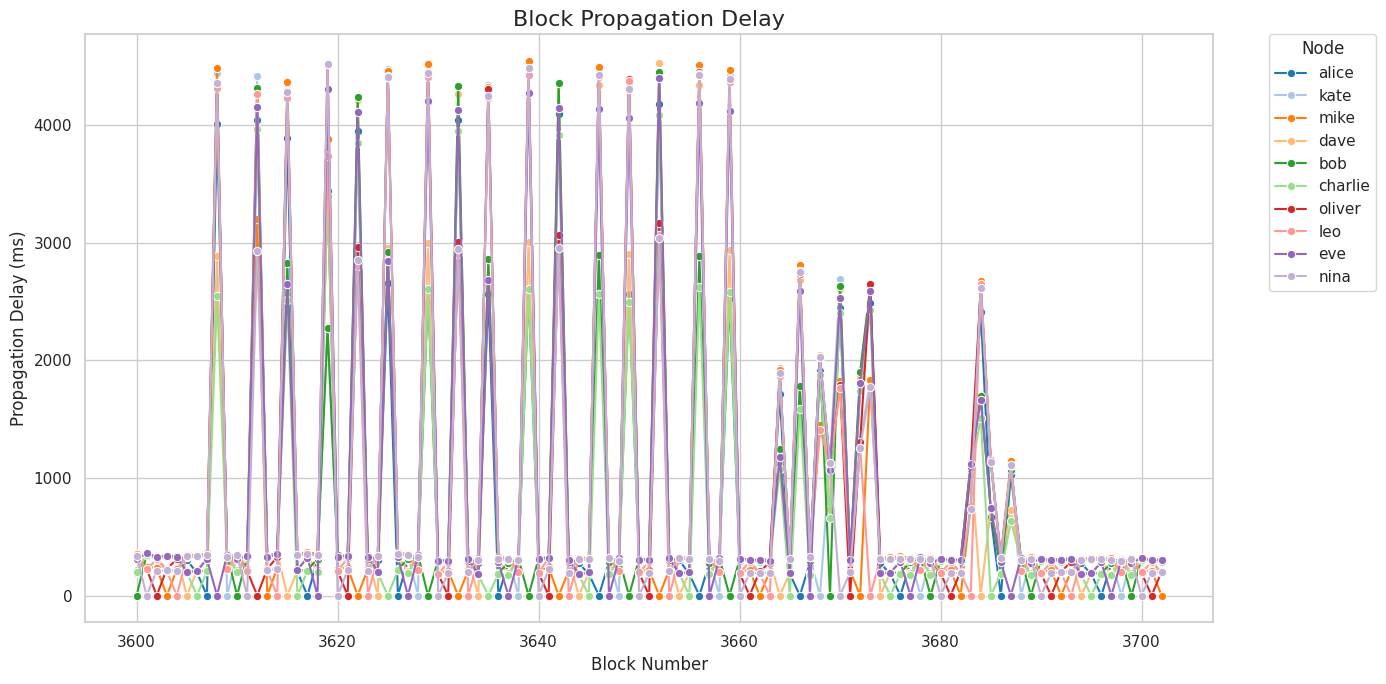

In [16]:
# ---------------------------------------------------------
# Plot all block import times
# ---------------------------------------------------------




# ---------------------------------------------------------
# STEP 2: HELPER FUNCTIONS
# ---------------------------------------------------------

def to_short_hash(full_hash):
    """
    Converts a full hash (e.g. 0xf2d38b...ed171) to the log format (0xf2d3…d171).
    Standard Substrate log format is usually: 0x + first 4 + … + last 4
    """
    if not full_hash.startswith("0x"):
        return full_hash
    
    # Remove 0x prefix for slicing
    clean = full_hash[2:]
    if len(clean) < 8: return full_hash
    
    return f"0x{clean[:4]}…{clean[-4:]}"

# ---------------------------------------------------------
# STEP 3: PARSE THE FILES
# ---------------------------------------------------------

# Dictionary to store creation times keyed by the BLOCK HASH (Short format)
# Key: ShortHash (str), Value: { 'time': datetime, 'block_num': int, 'node': str }
creation_registry = {}

# List to store raw import events to be processed later
# Item: { 'time': datetime, 'block_num': int, 'short_hash': str, 'node': str }
import_events = []

# Regex patterns
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")

# Capture Creation: "Pre-sealed block for proposal at 3040. Hash now 0xf2d3..."
# We use the "Pre-sealed" line because it contains the final finalized hash.
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)\. Hash now (0x[a-fA-F0-9]+)")

# Capture Import: "Imported #3040 (0x4e7c…cc64 → 0xf2d3…d171)"
# We capture Group 1 (Block Num) and Group 2 (The second hash, which is the new block hash)
import_pattern = re.compile(r"Imported #(\d+) \(.*? → (0x[a-fA-F0-9…\.]+)\)")

print(f"Reading logs from: {LOG_DIR}")

for node in NODES:
    filepath = os.path.join(LOG_DIR, f"{node}.txt")
    
    if not os.path.exists(filepath):
        print(f"  - Warning: Log file not found for {node}")
        continue
        
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            
            # 1. Extract Timestamp
            ts_match = timestamp_pattern.search(line)
            if not ts_match: continue
            
            try:
                ts_str = ts_match.group(1)
                # Truncate microseconds if too long (Python limit)
                if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26] 
                current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
            except ValueError:
                continue 

            # 2. Check for BLOCK CREATION (The Source of Truth)
            create_match = creation_pattern.search(line)
            if create_match:
                block_num = int(create_match.group(1))
                full_hash = create_match.group(2)
                short_hash = to_short_hash(full_hash)
                
                # We store this hash as the canonical creation event
                creation_registry[short_hash] = {
                    'time': current_time,
                    'block_num': block_num,
                    'creator': node
                }
                continue

            # 3. Check for BLOCK IMPORT
            import_match = import_pattern.search(line)
            if import_match:
                block_num = int(import_match.group(1))
                imported_hash = import_match.group(2)
                
                import_events.append({
                    'time': current_time,
                    'block_num': block_num,
                    'short_hash': imported_hash,
                    'node': node
                })

print(f"Processing complete.")
print(f"  - Unique Blocks Created: {len(creation_registry)}")
print(f"  - Total Import Events: {len(import_events)}")

# ---------------------------------------------------------
# STEP 4: CALCULATE LATENCY (MATCHING BY HASH)
# ---------------------------------------------------------

data = []

for event in import_events:
    target_hash = event['short_hash']
    importer = event['node']
    import_time = event['time']
    
    # Only calculate if we have a creation record for THIS SPECIFIC HASH
    if target_hash in creation_registry:
        genesis_info = creation_registry[target_hash]
        creation_time = genesis_info['time']
        creator = genesis_info['creator']
        block_num = genesis_info['block_num']
        
        # If this node is the creator, latency is 0
        if importer == creator:
            delay_ms = 0.0
        else:
            delta = import_time - creation_time
            delay_ms = delta.total_seconds() * 1000.0
        
        data.append({
            "Block": block_num,
            "Node": importer,
            "ImportTime_ms": delay_ms,
            "Hash": target_hash
        })

# ---------------------------------------------------------
# STEP 5: PLOT
# ---------------------------------------------------------

if not data:
    print("No matching hash data found! Check if the log format matches the patterns.")
else:
    df = pd.DataFrame(data)
    df = df.sort_values(by="Block")
    
    # Display sample to verify
    print("\nSample Data (First 5 rows):")
    print(df.head())

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df, 
        x="Block", 
        y="ImportTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab20", 
        linewidth=1.5,
        errorbar=None 
    )

    plt.title("Block Propagation Delay", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Propagation Delay (ms)", fontsize=12)
    
    # Formatting X-axis
    if df["Block"].nunique() < 20:
        plt.xticks(df["Block"].unique())

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Node")
    plt.tight_layout()
    
    plt.savefig("import_times_hash_matched.png", dpi=300)
    print("\nGraph saved as 'import_times_hash_matched.png'")
    
    plt.show()

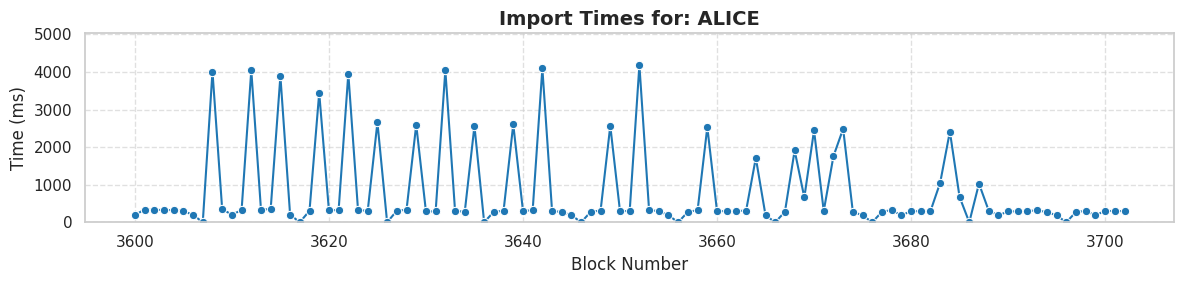

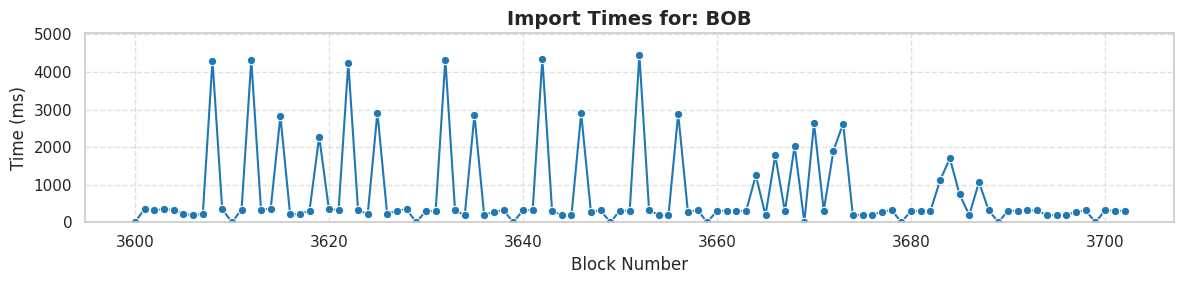

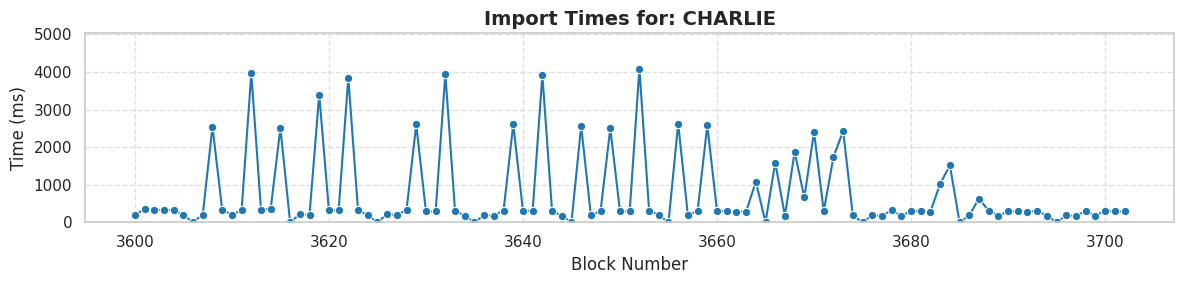

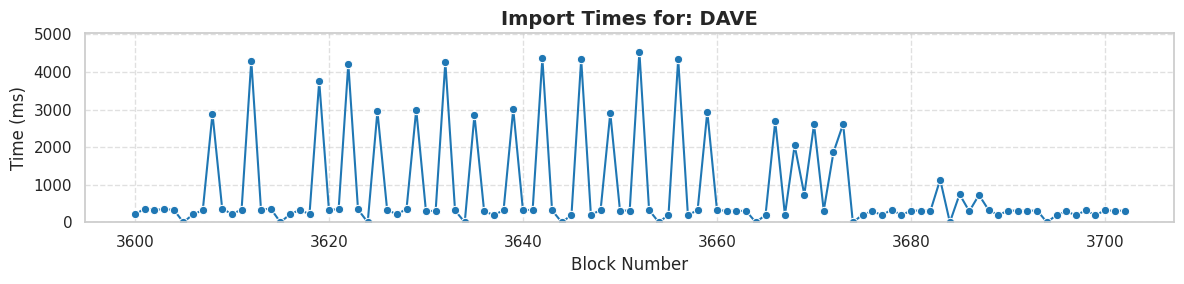

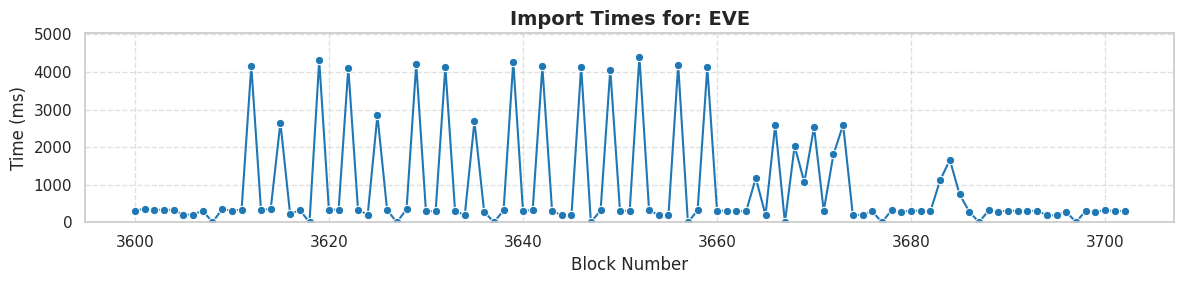

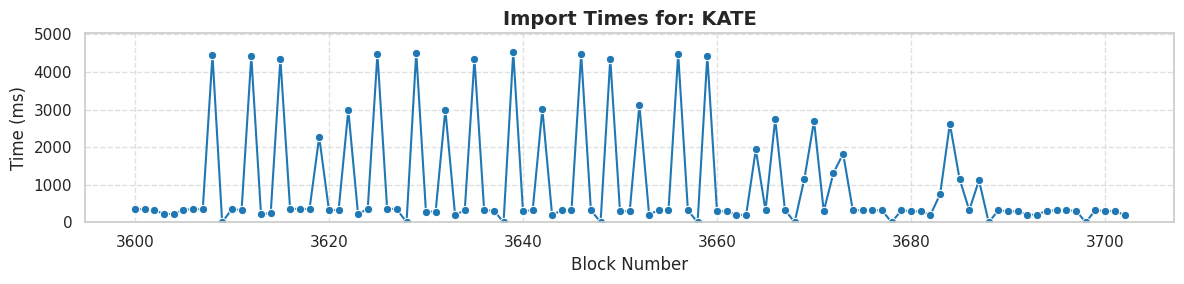

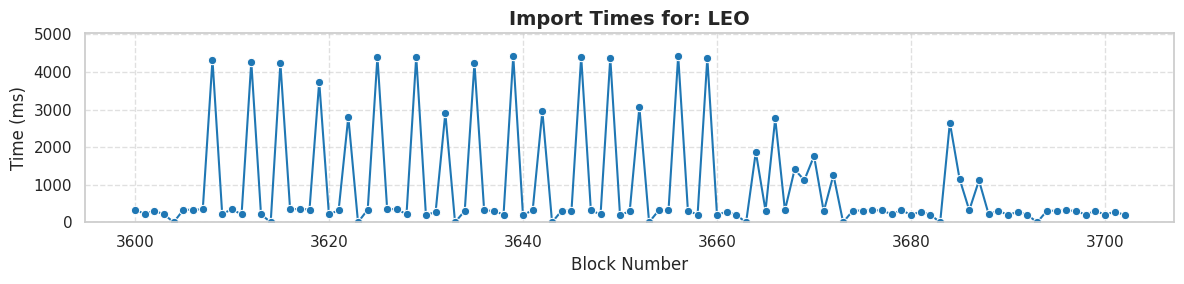

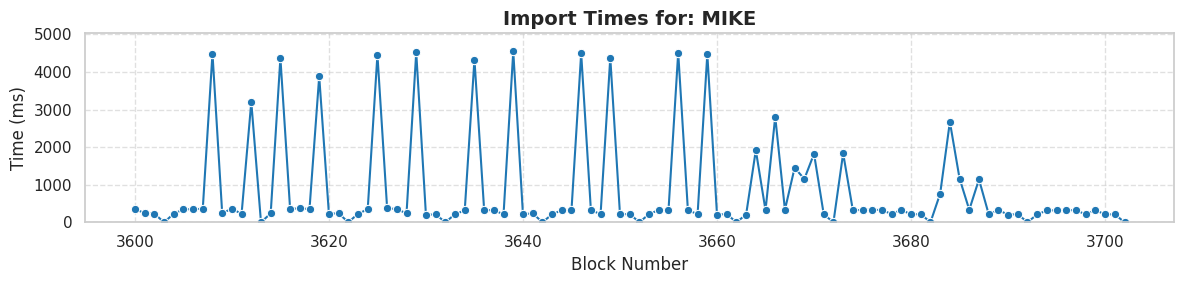

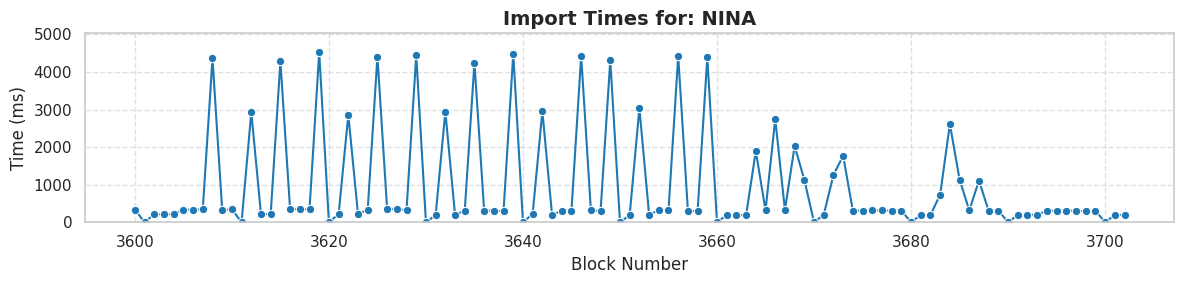

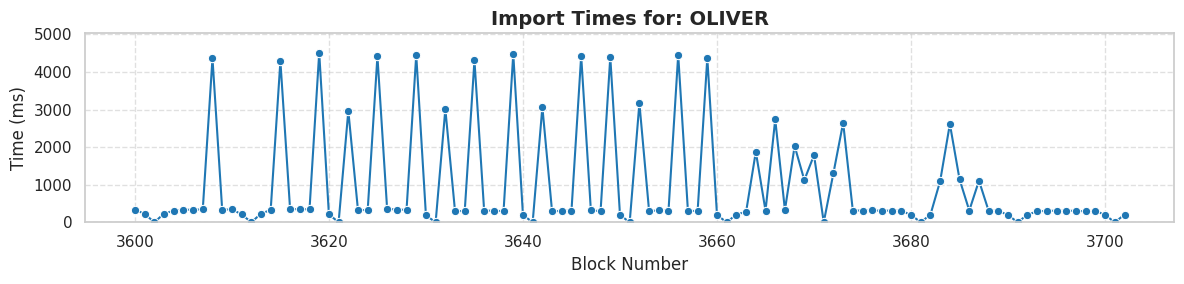

In [17]:
# ---------------------------------------------------------
# Plot block import times per node
# ---------------------------------------------------------


# 1. PRE-CALCULATE THE Y-AXIS LIMIT
# Find the max value in the whole dataset and add a 10% buffer for visual spacing
max_val = df['ImportTime_ms'].max()
global_y_limit = max_val * 1.1 

# Get a list of all unique nodes and sort them alphabetically
nodes = sorted(df['Node'].unique())

# Loop through each node and create a separate graph
for node in nodes:
    # Filter the data for just this node
    node_data = df[df['Node'] == node]
    
    # Create a new figure for this node
    plt.figure(figsize=(12, 3)) 
    
    # Plot the line
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ImportTime_ms", 
        marker="o",
        color='tab:blue',
        errorbar=None
    )
    
    # Formatting
    plt.title(f"Import Times for: {node.upper()}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- CRITICAL CHANGE HERE ---
    # Force every plot to use the same 0 to Global Max scale
    plt.ylim(0, global_y_limit)
    # ----------------------------
    
    # Ensure X-axis shows every block integer (if list isn't too long)
    if len(df["Block"].unique()) < 50:
        plt.xticks(df["Block"].unique())
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Display the graph
    plt.show()






# Block Size Analysis

This notebook analyzes blockchain block sizes from CSV data generated by the block size benchmarking scripts.

## Setup

First, generate data using the block size analysis script:
```bash
python3 ../block_size_benchmarks/analyze_block_sizes.py --url ws://127.0.0.1:9944 --latest-n 100
```

In [ ]:
# import sys
# import os
# import csv
# import json
# import subprocess
# from datetime import datetime
from pathlib import Path
from IPython.display import Image, display

# Check for required library
try:
    from substrateinterface import SubstrateInterface
except ImportError:
    print("❌ Error: 'substrateinterface' library is missing.")
    print("Please install it by running: !pip install substrate-interface")
    raise

# ==========================================
# Configuration
# ==========================================
# WebSocket URL of the Substrate node
NODE_URL = "ws://ferdie.node.sc.iog.io:9944"

# Mode 1: Analyze latest N blocks
LATEST_N = 100

# Mode 2: Analyze specific range (Set LATEST_N = None to use this)
START_BLOCK = None  # e.g., 1000
END_BLOCK = None    # e.g., 2000

# Output configuration
OUTPUT_DIR = None   # Leave None to auto-generate based on range
SKIP_FETCH = False  # Set to True to use existing CSV
EXISTING_CSV_FILE = None # Path to CSV if SKIP_FETCH is True

# Path to the plotting script (plot_block_sizes.py)
# Assuming it is in the current working directory.
SCRIPTS_DIR = Path(".").resolve()

# ==========================================
# Helper Functions (Inlined from fetch_block_sizes.py)
# ==========================================

def connect_to_node(url: str) -> SubstrateInterface:
    """Connect to a Substrate node via WebSocket."""
    try:
        print(f"Connecting to node at {url}...")
        substrate = SubstrateInterface(url=url)
        print(f"Connected successfully! Chain: {substrate.chain}")
        return substrate
    except Exception as e:
        raise Exception(f"Error connecting to node: {e}")

def get_block_size(substrate: SubstrateInterface, block_hash=None) -> dict:
    """Get the size of a block in bytes."""
    try:
        # Get block data
        block = substrate.get_block(block_hash=block_hash)
        if not block:
            return None
        
        block_number = block['header']['number']
        block_hash_str = block['header']['hash']
        extrinsics = block.get('extrinsics', [])
        extrinsic_count = len(extrinsics)
        
        # Calculate block size using SCALE encoding
        try:
            # Use the substrate RPC to get the raw block
            block_data = substrate.rpc_request('chain_getBlock', [block_hash_str])
            if block_data and 'result' in block_data:
                block_hex = block_data['result']['block']
                block_json_str = json.dumps(block_hex)
                size_bytes = len(block_json_str.encode('utf-8'))
            else:
                size_bytes = len(str(block).encode('utf-8'))
        except Exception:
            size_bytes = len(str(block).encode('utf-8'))
        
        # Get block timestamp
        timestamp = None
        try:
            for extrinsic in extrinsics:
                if hasattr(extrinsic, 'call_module'):
                    if extrinsic.call_module == 'Timestamp' and extrinsic.call_function == 'set':
                        if hasattr(extrinsic, 'params') and extrinsic.params:
                            timestamp_ms = extrinsic.params[0]['value']
                            timestamp = datetime.fromtimestamp(timestamp_ms / 1000)
                            break
                elif isinstance(extrinsic, dict):
                    call = extrinsic.get('call', {})
                    if call.get('call_module') == 'Timestamp' and call.get('call_function') == 'set':
                        call_args = call.get('call_args', [])
                        if call_args:
                            timestamp_ms = call_args[0]['value']
                            timestamp = datetime.fromtimestamp(timestamp_ms / 1000)
                            break
        except Exception:
            pass
        
        return {
            'block_number': block_number,
            'block_hash': block_hash_str,
            'size_bytes': size_bytes,
            'size_kb': size_bytes / 1024,
            'size_mb': size_bytes / (1024 * 1024),
            'timestamp': timestamp,
            'extrinsic_count': extrinsic_count
        }
    except Exception as e:
        print(f"Error getting block size for block {block_hash}: {e}")
        return None

def fetch_block_range(substrate: SubstrateInterface, start_block: int, end_block: int) -> list:
    """Fetch block sizes for a range of blocks."""
    block_data = []
    total_blocks = end_block - start_block + 1
    print(f"\nFetching blocks {start_block} to {end_block} ({total_blocks} blocks)...")
    
    for block_num in range(start_block, end_block + 1):
        try:
            block_hash = substrate.get_block_hash(block_num)
            block_info = get_block_size(substrate, block_hash=block_hash)
            
            if block_info:
                block_data.append(block_info)
                progress = ((block_num - start_block + 1) / total_blocks) * 100
                print(f"Progress: {progress:.1f}% - Block #{block_num}: {block_info['size_kb']:.2f} KB", end='\r')
        except Exception as e:
            print(f"\nWarning: Could not fetch block {block_num}: {e}")
            continue
    print()
    return block_data

def save_to_csv(block_data: list, output_file: Path):
    """Save block data to CSV file."""
    if not block_data:
        print("No block data to save.")
        return
    
    fieldnames = ['block_number', 'block_hash', 'size_bytes', 'size_kb', 'size_mb', 'extrinsic_count', 'timestamp']
    try:
        with open(output_file, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(block_data)
        
        print(f"\nData saved to: {output_file}")
        total_bytes = sum(b['size_bytes'] for b in block_data)
        print(f"Summary: Avg {total_bytes / len(block_data) / 1024:.2f} KB | Total {total_bytes/(1024*1024):.2f} MB")
    except Exception as e:
        raise Exception(f"Error saving to CSV: {e}")

# ==========================================
# Main Execution Logic
# ==========================================

# Determine output directory
if OUTPUT_DIR:
    output_path = Path(OUTPUT_DIR)
else:
    if LATEST_N:
        dir_name = f"block_size_analysis_latest_{LATEST_N}"
    elif START_BLOCK is not None and END_BLOCK is not None:
        dir_name = f"block_size_analysis_{START_BLOCK}_to_{END_BLOCK}"
    else:
        dir_name = "block_size_analysis"
    output_path = SCRIPTS_DIR / dir_name

output_path.mkdir(parents=True, exist_ok=True)
csv_path = output_path / "block_sizes.csv"

print("=" * 60)
print("BLOCK SIZE ANALYSIS")
print("=" * 60)
print(f"Output Directory: {output_path}\n")

# --- Step 1: Fetch Block Data ---
if not SKIP_FETCH:
    print("STEP 1: Fetching block size data...")
    print("-" * 60)
    
    try:
        substrate = connect_to_node(NODE_URL)
        
        # Determine range
        if LATEST_N:
            latest_block = substrate.get_block()
            end_block_num = latest_block['header']['number']
            start_block_num = max(0, end_block_num - LATEST_N + 1)
            print(f"Targeting latest {LATEST_N} blocks")
        elif START_BLOCK is not None and END_BLOCK is not None:
            start_block_num = START_BLOCK
            end_block_num = END_BLOCK
        else:
            raise ValueError("Either LATEST_N or both START_BLOCK and END_BLOCK must be set.")
            
        # Fetch and Save
        data = fetch_block_range(substrate, start_block_num, end_block_num)
        save_to_csv(data, csv_path)
        substrate.close()
        
    except Exception as e:
        print(f"\n❌ Error during fetch: {e}")
        # Stop execution if fetch fails
        raise

else:
    # Use existing CSV
    if EXISTING_CSV_FILE:
        csv_path = Path(EXISTING_CSV_FILE)
        if not csv_path.exists():
            print(f"❌ Error: CSV file not found: {csv_path}")
        else:
            print(f"Using existing CSV file: {csv_path}")
    else:
        print("❌ Error: EXISTING_CSV_FILE must be provided if SKIP_FETCH is True")

# --- Step 2: Generate Visualizations ---
if csv_path.exists():
    print("\nSTEP 2: Generating visualizations...")
    print("-" * 60)
    
    plot_script = SCRIPTS_DIR / "plot_block_sizes.py"
    
    if not plot_script.exists():
        print(f"❌ Error: Could not find '{plot_script.name}' in {SCRIPTS_DIR}")
        print("Please ensure the plot_block_sizes.py script is in the current directory.")
    else:
        plot_cmd = [
            sys.executable,
            str(plot_script),
            "--input", str(csv_path),
            "--output-dir", str(output_path)
        ]
        
        try:
            result = subprocess.run(plot_cmd, capture_output=True, text=True)
            print(result.stdout)
            if result.stderr:
                print("Errors:", result.stderr)
            
            if result.returncode == 0:
                print("=" * 60)
                print("ANALYSIS COMPLETE")
                print("=" * 60)
                
                # Display the dashboard inline
                dashboard_img = output_path / "block_size_analysis_dashboard.png"
                if dashboard_img.exists():
                    print("\n📊 Dashboard Preview:")
                    display(Image(filename=str(dashboard_img)))
                
                # Print the text report
                report_file = output_path / "block_size_report.txt"
                if report_file.exists():
                    print("\n📄 Report Summary:")
                    with open(report_file, 'r') as f:
                        print(f.read())
                        
        except Exception as e:
            print(f"❌ Error generating visualizations: {e}")
else:
    print("\n⚠️ Skipping visualization: CSV file was not generated or found.")


In [ ]:
#import pandas as pd
#import matplotlib.pyplot as plt
import numpy as np
#from pathlib import Path

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## Load Data

Update the path to your CSV file:

In [ ]:
# Update this path to your CSV file
csv_file = "../block_size_benchmarks/block_size_analysis_latest_100/block_sizes.csv"

# Load data
df = pd.read_csv(csv_file)

# Display basic info
print(f"Loaded {len(df)} blocks")
print(f"Block range: #{df['block_number'].min()} to #{df['block_number'].max()}")
df.head()

## Summary Statistics

In [ ]:
print("=" * 60)
print("BLOCK SIZE STATISTICS")
print("=" * 60)
print(f"Average block size:     {df['size_kb'].mean():.2f} KB")
print(f"Median block size:      {df['size_kb'].median():.2f} KB")
print(f"Min block size:         {df['size_kb'].min():.2f} KB")
print(f"Max block size:         {df['size_kb'].max():.2f} KB")
print(f"Std deviation:          {df['size_kb'].std():.2f} KB")
print(f"Total data:             {df['size_mb'].sum():.2f} MB")
print()
print("EXTRINSIC STATISTICS")
print("=" * 60)
print(f"Total extrinsics:       {df['extrinsic_count'].sum():,}")
print(f"Average per block:      {df['extrinsic_count'].mean():.1f}")
print(f"Min per block:          {df['extrinsic_count'].min()}")
print(f"Max per block:          {df['extrinsic_count'].max()}")

## Block Size Over Time

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['block_number'], df['size_kb'], marker='o', markersize=4, linewidth=1.5, alpha=0.7)
ax.axhline(y=df['size_kb'].mean(), color='r', linestyle='--', linewidth=2, label=f"Average: {df['size_kb'].mean():.2f} KB")

ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('Block Size (KB)', fontsize=12)
ax.set_title('Block Size Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Block Size Distribution

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax1.hist(df['size_kb'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(df['size_kb'].mean(), color='r', linestyle='--', linewidth=2, label='Mean')
ax1.axvline(df['size_kb'].median(), color='g', linestyle='--', linewidth=2, label='Median')
ax1.set_xlabel('Block Size (KB)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Block Size Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Box plot
ax2.boxplot(df['size_kb'], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Block Size (KB)', fontsize=12)
ax2.set_title('Block Size Box Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Block Size vs Extrinsic Count

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df['extrinsic_count'], df['size_kb'], alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

# Add trend line
if len(df) > 1:
    z = np.polyfit(df['extrinsic_count'], df['size_kb'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df['extrinsic_count'].min(), df['extrinsic_count'].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Trend: y = {z[0]:.2f}x + {z[1]:.2f}')

ax.set_xlabel('Number of Extrinsics', fontsize=12)
ax.set_ylabel('Block Size (KB)', fontsize=12)
ax.set_title('Block Size vs Number of Extrinsics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Top 10 Largest Blocks

In [ ]:
top_blocks = df.nlargest(10, 'size_kb')[['block_number', 'size_kb', 'extrinsic_count']]
top_blocks.reset_index(drop=True, inplace=True)
top_blocks.index = top_blocks.index + 1
print("Top 10 Largest Blocks:")
print(top_blocks.to_string())

## Size per Extrinsic Analysis

In [ ]:
# Calculate average size per extrinsic for each block
df['size_per_extrinsic'] = df['size_kb'] / df['extrinsic_count'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['block_number'], df['size_per_extrinsic'], marker='o', markersize=4, linewidth=1.5, alpha=0.7, color='orange')
ax.axhline(y=df['size_per_extrinsic'].mean(), color='r', linestyle='--', linewidth=2, 
           label=f"Average: {df['size_per_extrinsic'].mean():.2f} KB/extrinsic")

ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('KB per Extrinsic', fontsize=12)
ax.set_title('Average Size per Extrinsic Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Custom Analysis

Add your own analysis cells below:

In [ ]:
# Your custom analysis here

## Forks

I am not sure how accurate this is, it shows 2 forks when grafana shows 3 forks. More testing needed.


Reading logs from: /home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28
Processed 10 files.
  Raw block imports: 1040
  After dedup: 1040 (removed 0 duplicates)
  Finalization events: 1251

Height range: 3600 to 3702
Time range: 2026-01-27 21:34:06.102000 to 2026-01-27 21:44:24.417000

SUMMARY

--- Unique blocks per node per height ---
Node     Height
Alice    3619      2
Bob      3619      2
Charlie  3619      2
Dave     3619      2
Eve      3619      2
Kate     3619      2
Leo      3619      2
Mike     3619      2
Nina     3619      2
Oliver   3619      2
Name: Hash, dtype: int64

--- Max Total Concurrent Tips per Node ---
Node
Nina       5
Alice      4
Bob        4
Charlie    4
Eve        4
Dave       4
Kate       4
Leo        4
Mike       4
Oliver     4
Name: TotalTips, dtype: int64

Overall max concurrent tips: 5

--- Max Fork Depth (at single height) per Node ---
Node
Alice      2
Bob        2
Charlie    2
Dave  

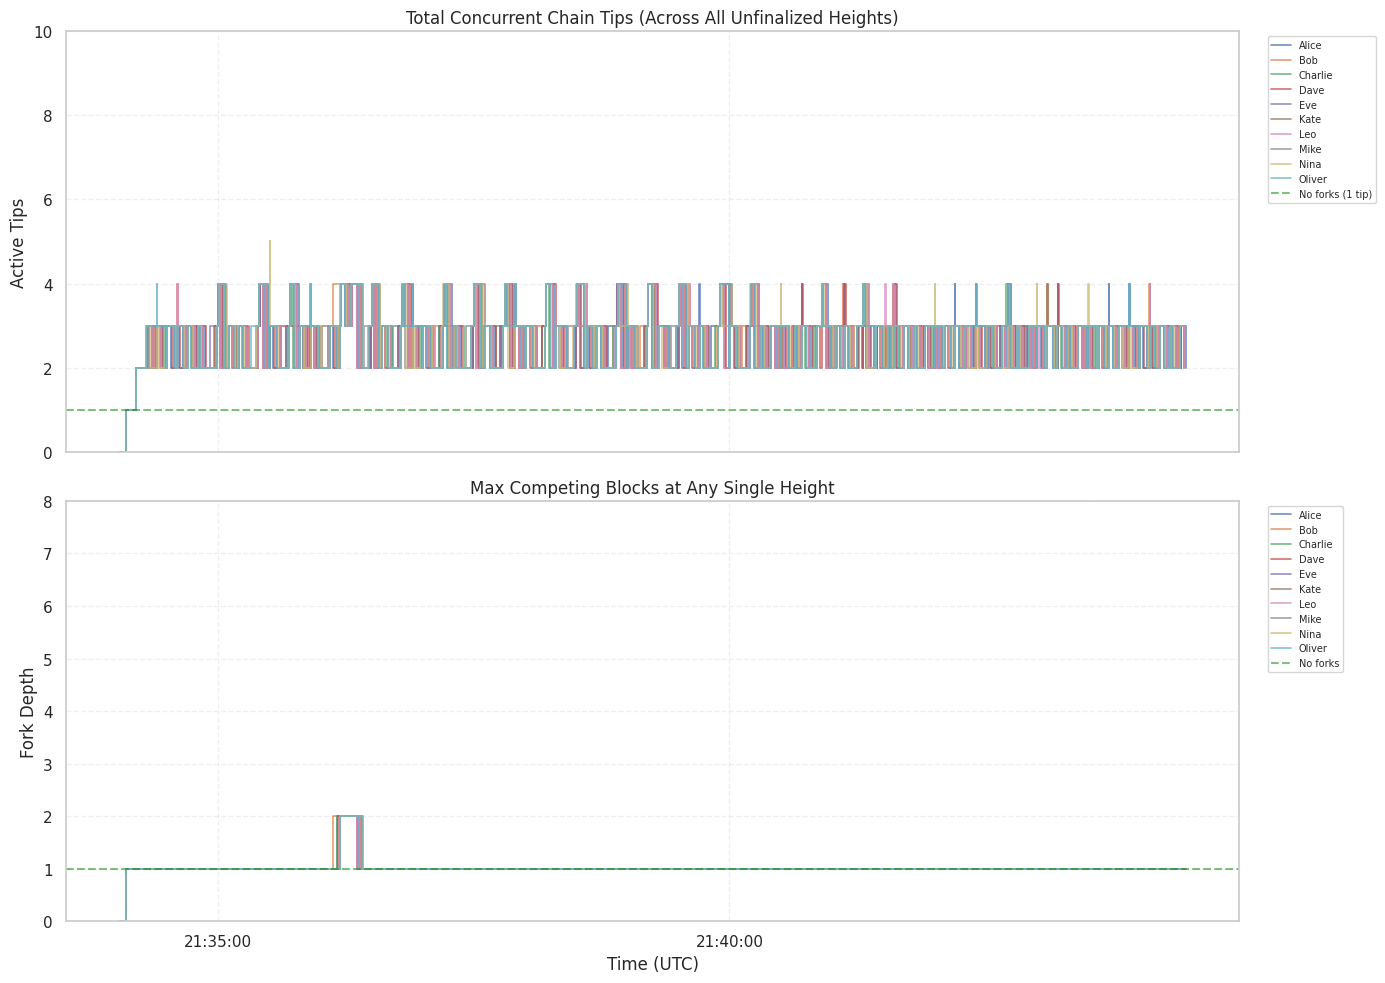

In [18]:
# Regex for block imports
log_pattern = re.compile(
    r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*?'
    r'Imported #(\d+)\s*'
    r'\((0x[a-f0-9]{4})[^\)]*?'
    r'(?:→|->|\xe2\x86\x92)\s*'
    r'(0x[a-f0-9]{4})[^\)]*\)'
)

# Regex for finalization events
finalized_pattern = re.compile(
    r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*?'
    r'finalized #(\d+)'
)

def load_logs(log_dir, node_list):
    imports = []
    finalizations = []
    print(f"Reading logs from: {log_dir}")
    
    files_read = 0
    for node in node_list:
        filename = f"{node}.txt"
        file_path = os.path.join(log_dir, filename)
        
        if os.path.exists(file_path):
            files_read += 1
            with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
                for line in f:
                    if "Imported #" in line:
                        match = log_pattern.search(line)
                        if match:
                            ts, height, parent, hash_prefix = match.groups()
                            dt = datetime.strptime(ts, '%Y-%m-%d %H:%M:%S.%f')
                            imports.append({
                                'Node': node.capitalize(),
                                'Time': dt,
                                'Height': int(height),
                                'Hash': hash_prefix,
                                'Parent': parent,
                            })
                    
                    if "finalized #" in line:
                        match = finalized_pattern.search(line)
                        if match:
                            ts, height = match.groups()
                            dt = datetime.strptime(ts, '%Y-%m-%d %H:%M:%S.%f')
                            finalizations.append({
                                'Node': node.capitalize(),
                                'Time': dt,
                                'FinalizedHeight': int(height),
                            })
    
    imports_df = pd.DataFrame(imports)
    finals_df = pd.DataFrame(finalizations)
    
    # CRITICAL: Deduplicate imports - keep first occurrence of each (Node, Height, Hash)
    if not imports_df.empty:
        before = len(imports_df)
        imports_df = imports_df.sort_values('Time').drop_duplicates(
            subset=['Node', 'Height', 'Hash'], 
            keep='first'
        )
        after = len(imports_df)
        print(f"Processed {files_read} files.")
        print(f"  Raw block imports: {before}")
        print(f"  After dedup: {after} (removed {before - after} duplicates)")
        print(f"  Finalization events: {len(finals_df)}")
    
    return imports_df, finals_df

def calculate_concurrent_tips(imports_df, finalizations_df):
    """
    Calculate concurrent active chain tips over time per node.
    A tip is active from when it's imported until its height is finalized.
    """
    if imports_df.empty:
        return pd.DataFrame()
    
    results = []
    
    for node in imports_df['Node'].unique():
        node_imports = imports_df[imports_df['Node'] == node].copy()
        node_finals = finalizations_df[finalizations_df['Node'] == node].copy() if not finalizations_df.empty else pd.DataFrame()
        
        # Build event timeline
        events = []
        for _, row in node_imports.iterrows():
            events.append({
                'time': row['Time'],
                'type': 'import',
                'height': row['Height'],
                'hash': row['Hash']
            })
        
        if not node_finals.empty:
            for _, row in node_finals.iterrows():
                events.append({
                    'time': row['Time'],
                    'type': 'finalize',
                    'height': row['FinalizedHeight'],
                    'hash': None
                })
        
        events.sort(key=lambda x: x['time'])
        
        # Track state
        active_blocks = {}  # (height, hash) -> True
        finalized_height = 0
        
        for evt in events:
            if evt['type'] == 'import':
                key = (evt['height'], evt['hash'])
                if key not in active_blocks:
                    active_blocks[key] = True
            
            elif evt['type'] == 'finalize':
                finalized_height = max(finalized_height, evt['height'])
                # Remove all blocks at or below finalized height
                active_blocks = {k: v for k, v in active_blocks.items() 
                                if k[0] > finalized_height}
            
            # Calculate metrics at this point in time
            if active_blocks:
                # Group by height
                by_height = {}
                for (h, bhash) in active_blocks.keys():
                    if h not in by_height:
                        by_height[h] = set()
                    by_height[h].add(bhash)
                
                # Total unique tips across all unfinalized heights
                total_tips = sum(len(hashes) for hashes in by_height.values())
                
                # Max competing at any single height
                max_at_height = max(len(hashes) for hashes in by_height.values())
                
                # Number of heights with forks (>1 block)
                forked_heights = sum(1 for hashes in by_height.values() if len(hashes) > 1)
            else:
                total_tips = 0
                max_at_height = 0
                forked_heights = 0
            
            results.append({
                'Node': node,
                'Time': evt['time'],
                'TotalTips': total_tips,
                'MaxAtHeight': max_at_height,
                'ForkedHeights': forked_heights,
                'FinalizedHeight': finalized_height,
            })
    
    return pd.DataFrame(results)

def plot_results(df):
    if df.empty:
        print("No data to plot")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    nodes = sorted(df['Node'].unique())
    
    # Plot 1: Total concurrent tips (should match Grafana)
    ax1 = axes[0]
    for node in nodes:
        node_data = df[df['Node'] == node].sort_values('Time')
        ax1.step(node_data['Time'], node_data['TotalTips'], 
                 where='post', label=node, linewidth=1.2, alpha=0.8)
    ax1.set_title("Total Concurrent Chain Tips (Across All Unfinalized Heights)")
    ax1.set_ylabel("Active Tips")
    ax1.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='No forks (1 tip)')
    ax1.set_ylim(0, 10)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    
    # Plot 2: Max forks at single height
    ax2 = axes[1]
    for node in nodes:
        node_data = df[df['Node'] == node].sort_values('Time')
        ax2.step(node_data['Time'], node_data['MaxAtHeight'], 
                 where='post', label=node, linewidth=1.2, alpha=0.8)
    ax2.set_title("Max Competing Blocks at Any Single Height")
    ax2.set_ylabel("Fork Depth")
    ax2.set_xlabel("Time (UTC)")
    ax2.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='No forks')
    ax2.set_ylim(0, 8)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    
    plt.tight_layout()
    plt.show()

def print_summary(df, imports_df):
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    
    # Verify deduplication worked
    print("\n--- Unique blocks per node per height ---")
    check = imports_df.groupby(['Node', 'Height'])['Hash'].nunique()
    forked = check[check > 1]
    print(forked)
    
    print("\n--- Max Total Concurrent Tips per Node ---")
    max_tips = df.groupby('Node')['TotalTips'].max().sort_values(ascending=False)
    print(max_tips)
    print(f"\nOverall max concurrent tips: {df['TotalTips'].max()}")
    
    print("\n--- Max Fork Depth (at single height) per Node ---")
    max_depth = df.groupby('Node')['MaxAtHeight'].max().sort_values(ascending=False)
    print(max_depth)
    print(f"\nOverall max fork depth: {df['MaxAtHeight'].max()}")

# --- Execution ---
imports_df, finals_df = load_logs(LOG_DIR, NODES)

if not imports_df.empty:
    print(f"\nHeight range: {imports_df['Height'].min()} to {imports_df['Height'].max()}")
    print(f"Time range: {imports_df['Time'].min()} to {imports_df['Time'].max()}")
    
    metrics_df = calculate_concurrent_tips(imports_df, finals_df)
    print_summary(metrics_df, imports_df)
    plot_results(metrics_df)
else:
    print("No data found.")